In [1]:
import numpy as np
from scipy.stats import linregress
from utils import load_data, load_param
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from data_analysis import fit_linear_background_iterative
from glob import glob
from science import laser_current_to_freq_MHz, get_852_RabiFreq_MHz, laser_current_to_freq_MHz_2

In [2]:
def reduced_data(filename):
    x, y = load_data(filename)
    y = y-(-0.013)
    a, b, _, _ = fit_linear_background_iterative(x,y, n_iter=3)
    yf = y/(a* x + b)
    xf = laser_current_to_freq_MHz_2(x, 72.835)
    return xf[20:120], yf[20:120], np.average(a*x + b -(-0.013))

In [14]:
#p852_mW=3 data
#parent = "04122026/04122026-130418-spec/"
#p852_mw= 7.327
parent = "04132026/data-p852=7.3mW/"

#852_mW=11.1 data
#parent = "04112026/04112026-154320-spec/"
dataf_ls = np.sort(glob(parent+"data_*.csv"))[20:80]
paramf_ls = np.sort(glob(parent+"params_*.json"))[20:80]
print(len(dataf_ls))

l2_pos_deg = [load_param(paramf)["l2_position_deg"] for paramf in paramf_ls]
bg = [np.average(load_data(dataf)[1][-20:-1]) for dataf in dataf_ls]
max_bg = 0.8126273684210527
print(max_bg)
plt.plot(l2_pos_deg, bg, "x")


60
0.8126273684210527


qt.qpa.wayland: Creating a fake screen in order for Qt not to crash


In [15]:
P852_W = load_param(paramf_ls[0])["p852_mW"]
Omega_852 = get_852_RabiFreq_MHz(P852_W)
print(Omega_852)

detuning_ls = reduced_data(dataf_ls[0])[0]
RabiFreq_ls = np.array([])
signal = [] 
for i in range(len(dataf_ls)):
    dataf = dataf_ls[i]
    paramf = paramf_ls[i]
    _, z, y = reduced_data(dataf)
    RabiFreq_ls = np.append(RabiFreq_ls, (62.04/6.28) * np.sqrt(y/max_bg))
    signal.append(z)
signal = np.array(signal)
OD=-np.log(signal)
norm= colors.PowerNorm(1.1, vmax=0.6, vmin=-0.1)
norm=colors.LogNorm(vmax=0.4, vmin=-0.1)

plt.figure(figsize=(6,4))
print(len(RabiFreq_ls))
X, Y = np.meshgrid(detuning_ls,RabiFreq_ls)
plt.pcolormesh(X, Y, OD, cmap="afmhot")
plt.colorbar(label=r"OD $= -\ln(I/I_0)$", norm=norm)
plt.xlabel(r"Detuning $\Delta_{3491}$ (MHz)")
plt.ylabel(r"Rabi Frequency $\Omega_{3491}$ ($2\pi \times$ MHz)")
plt.title(fr"$\Omega_{{852}}$= $2 \pi \times {Omega_852:.0f}$ MHz")


#a = -100
#ymin=6
#ymax=40
#6->5
#plt.vlines(a, ymin, ymax, color="blue")
#5->5
#plt.vlines(a+127.4, ymin, ymax, color="red")
#4->5
#plt.vlines(a+127.4+106.2, ymin, ymax, color="blue")
#5->4
#plt.vlines(a+127.4+251.1, ymin, ymax, color="blue")
#4->4
#plt.vlines(a+127.4+106.2+251.1, ymin, ymax, color="blue")
#3->4
#plt.vlines(a+127.4+106.2+251.1+85, ymin, ymax, color="blue")
#4->3
#plt.vlines(a+ 127.4 +106.2 + 251.1+ 201.3, ymin, ymax, color="blue")
#3->3
#plt.vlines(a+ 127.4 +106.2 + 251.1+ 201.3+85, ymin, ymax, color="blue")
#3->2
#plt.vlines(a+ 127.4 +106.2 + 251.1+ 201.3+85+ 151.2, ymin, ymax, color="blue")


plt.show()

50.020625016777906
60


qt.qpa.wayland: Wayland does not support QWindow::requestActivate()


qt.qpa.wayland: Creating a fake screen in order for Qt not to crash
qt.qpa.wayland: Creating a fake screen in order for Qt not to crash


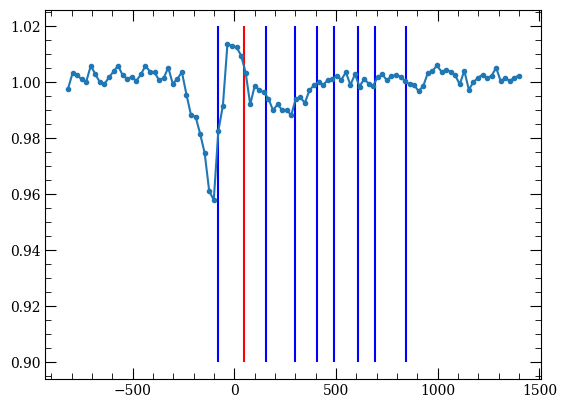

In [5]:
x,y,_ = reduced_data(dataf_ls[0])
a = -80
ymin=1.02
ymax=+0.9
#6->5
plt.vlines(a, ymin, ymax, color="blue")
#5->5
plt.vlines(a+127.4, ymin, ymax, color="red")
#4->5
plt.vlines(a+127.4+106.2, ymin, ymax, color="blue")
#5->4
plt.vlines(a+127.4+251.1, ymin, ymax, color="blue")
#4->4
plt.vlines(a+127.4+106.2+251.1, ymin, ymax, color="blue")
#3->4
plt.vlines(a+127.4+106.2+251.1+85, ymin, ymax, color="blue")
#4->3
plt.vlines(a+ 127.4 +106.2 + 251.1+ 201.3, ymin, ymax, color="blue")
#3->3
plt.vlines(a+ 127.4 +106.2 + 251.1+ 201.3+85, ymin, ymax, color="blue")
#3->2
plt.vlines(a+ 127.4 +106.2 + 251.1+ 201.3+85+ 151.2, ymin, ymax, color="blue")
plt.plot(x,y, ".-")

In [6]:
#%matplotlib widget 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.widgets import Slider, Button

%matplotlib qt

# --- your data setup (unchanged) ---
P852_W = load_param(paramf_ls[0])["p852_mW"]*1e-3
Omega_852 = get_852_RabiFreq_MHz(P852_W)

detuning_ls = reduced_data(dataf_ls[0])[0]
RabiFreq_ls = np.array([])
signal = []
for i in range(len(dataf_ls)):
    dataf = dataf_ls[i]
    if len(dataf) < 41:
        continue
    paramf = paramf_ls[i]
    _, z, y = reduced_data(dataf)
    RabiFreq_ls = np.append(RabiFreq_ls, (250 / 6.28) * np.sqrt(y / max_bg))
    signal.append(z)

signal = np.array(signal)
OD     = -np.log(signal)
X, Y   = np.meshgrid(detuning_ls, RabiFreq_ls)

od_min = float(np.nanmin(OD))
od_max = float(np.nanmax(OD))

# --- figure layout ---
fig, ax = plt.subplots(figsize=(7, 5))
plt.subplots_adjust(bottom=0.25)

mesh = ax.pcolormesh(X, Y, OD, cmap="afmhot", vmin=od_min, vmax=od_max)
cbar = fig.colorbar(mesh, ax=ax, label=r"OD $= -\ln(I/I_0)$")
ax.set_xlabel(r"Detuning $\Delta_{3491}$ (MHz)")
ax.set_ylabel(r"Rabi Frequency $\Omega_{3491}$ ($2\pi \times$ MHz)")
ax.set_title(r"$\Omega_{852}$ = $2\pi \times 96$ MHz")

# --- sliders ---
ax_vmin = plt.axes([0.15, 0.12, 0.65, 0.03])
ax_vmax = plt.axes([0.15, 0.06, 0.65, 0.03])

slider_vmin = Slider(ax_vmin, "vmin", od_min, od_max, valinit=od_min)
slider_vmax = Slider(ax_vmax, "vmax", od_min, od_max, valinit=od_max)

def update(val):
    vmin = slider_vmin.val
    vmax = slider_vmax.val
    if vmin < vmax:
        mesh.set_clim(vmin, vmax)
        fig.canvas.draw_idle()

slider_vmin.on_changed(update)
slider_vmax.on_changed(update)

# --- reset button ---
ax_reset = plt.axes([0.8, 0.01, 0.1, 0.04])
btn_reset = Button(ax_reset, "Reset")

def reset(event):
    slider_vmin.reset()
    slider_vmax.reset()

btn_reset.on_clicked(reset)

plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.widgets import Slider, Button
from matplotlib.animation import FuncAnimation

%matplotlib qt

# --- helper to build OD array from current data ---
def build_OD():
    RabiFreq_ls = np.array([])
    signal      = []
    for i in range(len(dataf_ls)):
        dataf = dataf_ls[i]
        if len(dataf) < 41:
            continue
        _, z, y = reduced_data(dataf)
        RabiFreq_ls = np.append(RabiFreq_ls, (62.04 / 6.28) * np.sqrt(y / max_bg))
        signal.append(z)
    signal = np.array(signal)
    OD     = -np.log(signal)
    return RabiFreq_ls, OD

# --- initial data ---
detuning_ls        = reduced_data(dataf_ls[0])[0]
RabiFreq_ls, OD    = build_OD()
X, Y               = np.meshgrid(detuning_ls, RabiFreq_ls)
od_min, od_max     = float(np.nanmin(OD)), float(np.nanmax(OD))

# --- figure ---
fig, ax = plt.subplots(figsize=(7, 5))
plt.subplots_adjust(bottom=0.25)

mesh = ax.pcolormesh(X, Y, OD, cmap="afmhot", vmin=od_min, vmax=od_max)
cbar = fig.colorbar(mesh, ax=ax, label=r"OD $= -\ln(I/I_0)$")
ax.set_xlabel(r"Detuning $\Delta_{3491}$ (MHz)")
ax.set_ylabel(r"Rabi Frequency $\Omega_{3491}$ ($2\pi \times$ MHz)")
ax.set_title(rf"$\Omega_{{852}}$ = $2\pi \times {Omega_852}$ MHz")

# --- sliders ---
ax_vmin     = plt.axes([0.15, 0.12, 0.65, 0.03])
ax_vmax     = plt.axes([0.15, 0.06, 0.65, 0.03])
slider_vmin = Slider(ax_vmin, "vmin", od_min, od_max, valinit=od_min)
slider_vmax = Slider(ax_vmax, "vmax", od_min, od_max, valinit=od_max)

def update_clim(val):
    if slider_vmin.val < slider_vmax.val:
        mesh.set_clim(slider_vmin.val, slider_vmax.val)
        fig.canvas.draw_idle()

slider_vmin.on_changed(update_clim)
slider_vmax.on_changed(update_clim)

ax_reset = plt.axes([0.8, 0.01, 0.1, 0.04])
btn_reset = Button(ax_reset, "Reset")
btn_reset.on_clicked(lambda e: [slider_vmin.reset(), slider_vmax.reset()])

# --- live update ---
INTERVAL_MS = 5 * 60 * 1000    # 5 minutes — change to e.g. 5000 for testing

def animate(frame):
    RabiFreq_ls, OD = build_OD()
    X, Y = np.meshgrid(detuning_ls, RabiFreq_ls)

    # redraw mesh with new data
    mesh.set_array(OD.ravel())
    mesh.set_clim(slider_vmin.val, slider_vmax.val)

    ax.set_title(
        r"$\Omega_{852}$ = $2\pi \times 96$ MHz"
        f"   [last update: {plt.matplotlib.dates.num2date(plt.matplotlib.dates.date2num(__import__('datetime').datetime.now())).strftime('%H:%M:%S')}]"
    )

ani = FuncAnimation(fig, animate, interval=INTERVAL_MS, cache_frame_data=False)

plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

In [ ]:
get_852_RabiFreq_MHz(3e-3)

np.float64(32.007123501697514)

In [9]:
from science import get_3491_RabiFreq_MHz

In [11]:
get_3491_RabiFreq_MHz(3.853)

np.float64(62.04383400757762)

In [ ]:
62 * 2 *3.14

389.36